FaultyCase1: Blokering af luftlinje
1.1: 1566-5181
1.2: 657-3777
1.3: 691-3691

FaultyCase2: Blokering af vandlinje
2.1: 2244-6616
2.2: 476-2656
2.3: 331-2467

FaultyCase3: Blokering ved separator indgangen
3.1: 1136-8352
3.2: 333-5871
3.3: 596-9566

FaultyCase4: Lækage (åben bypass)
4.1: 953-6294
4.2: 851-3851
4.3: 241-3241

FaultyCase5: Slugging (ustabile væskebælger i rørene)
5.1: Fault1 686-1172, Fault2 1772-2253
5.2: Fault 1 1633-2955, Fault2 7031-7553, Fault3 8057-10608

FaultyCase6: Uønsker tryksætning af en isoleret rørledning
6.1: 1723-2800
6.2: 1037-4830

Denne model indeholder lagged features, fordi DPCA udvider PCA ved at stacke nuværende og tidligere sensorværdier i en uvidet matrix. DPCA laver en augmented matrix med x(t), x(t-1), ..., x(t-L) og kører derefter almindelig PCA på den. 

## Data import

Vi finder projektmappen, tilføjer den til sys.path, importerer biblioteker og loader FaultyCase1.mat

Loader Set1_1, Set1_2 og Set1_3 som TimeSeriesDataset-objekter og fault_info gemmer fault-start og fault-end for hvert datasæt

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd()

while not ((cwd / "data").exists() or (cwd / "CVACaseStudy").exists()):
    if cwd.parent == cwd:
        raise RuntimeError("Kunne ikke finde projekt root")
    cwd = cwd.parent

PROJECT_ROOT = cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import f

from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor
from fdd.dataset import TimeSeriesDataset

def find_file(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"{filename} not found under {root}")
    return sorted(matches, key=lambda p: len(str(p)))[0]

DATA_PATH = find_file(PROJECT_ROOT, "FaultyCase1.mat")

loader = DataLoader(DATA_PATH)
datasets = loader.load()

fault_info = {
    "Set1_1": {"start": 1566, "end": 5181, "description": "Changing conditions"},
    "Set1_2": {"start": 657, "end": 3777, "description": "Steady-state 1"},
    "Set1_3": {"start": 691, "end": 3691, "description": "Steady-state 2"},
}

for name, ds in datasets.items():
    print(name, ds.summary())

Set1_1 TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)
Set1_2 TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)
Set1_3 TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


## Evalueringsfunktioner

Definerer målene til evaluering, laver en sand/falsk label serie, hvor 0 = normal og 1 = fault.

Måler fault detection performance
- Første alarm efter fault-start
- Detection delay
- Antal alarmer før, under og efter fault
- False alarm rate
- Fault detection rate 

Måler klassifikationsperformance
- Accuracy
- Precision
- Recall
- F1 score 

Denne blok er vigtig for FDA, fordi FDA er en supervised classifier

In [2]:
def make_ground_truth(n_samples, fault_start, fault_end):
    y = np.zeros(n_samples, dtype=int)
    y[fault_start:fault_end + 1] = 1
    return y


def evaluate_alarm(alarm, fault_start, fault_end):
    alarm = np.asarray(alarm).astype(bool)

    before_fault = alarm[:fault_start]
    during_fault = alarm[fault_start:fault_end + 1]
    after_fault = alarm[fault_end + 1:]

    alarm_indices_after_start = np.where(alarm[fault_start:])[0]

    if len(alarm_indices_after_start) == 0:
        first_alarm_after_fault = None
        detection_delay = None
    else:
        first_alarm_after_fault = int(alarm_indices_after_start[0] + fault_start)
        detection_delay = int(first_alarm_after_fault - fault_start)

    return {
        "first_alarm_after_fault": first_alarm_after_fault,
        "detection_delay": detection_delay,
        "n_alarms_total": int(alarm.sum()),
        "n_alarms_before_fault": int(before_fault.sum()),
        "n_alarms_during_fault": int(during_fault.sum()),
        "n_alarms_after_fault": int(after_fault.sum()),
        "false_alarm_rate_before_fault": float(before_fault.mean()) if len(before_fault) else np.nan,
        "fault_detection_rate": float(during_fault.mean()) if len(during_fault) else np.nan,
    }

## Healthy DPCA training dataset 

DPCA trænes kun på raske data, ligesom PCA. Modellen skal lære normal dynamisk adfærd 

The models were trained using only normal operating data (before fault occurrence), while the full datasets were used for testing. This time-based split reflects real industrial conditions, where fault-free data is available for model training, and faults must be detected during operation

In [3]:
healthy_parts = []

for name, dataset in datasets.items():
    fault_start = fault_info[name]["start"]
    healthy_parts.append(dataset.subset_rows(0, fault_start).sensors)

healthy_sensors = pd.concat(healthy_parts, ignore_index=True)

healthy_dataset = TimeSeriesDataset(
    name="Healthy_DPCA_training_data",
    sensors=healthy_sensors,
    metadata={"description": "All healthy samples before fault start"},
)

display(healthy_dataset.sensors.head())
print(healthy_dataset.summary())

,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.123671,0.118994,0.099840,0.102702,0.099423,0.019198,0.248773,0.020653,0.493771,-0.246817,...,995.862488,996.525513,20.018761,20.923019,21.754801,7.324118,21.015640,46.294441,28.072460,2.1050
1,0.123146,0.118504,0.099780,0.102566,0.099522,0.018732,0.288827,0.020645,0.493793,-0.246817,...,995.862610,996.518677,20.015230,20.922810,21.761770,7.321606,21.023270,46.311249,28.073271,2.0150
2,0.122749,0.118401,0.099980,0.102515,0.099621,0.018358,0.270946,0.020638,0.493816,-0.246818,...,995.862793,996.511780,20.011700,20.922609,21.768749,7.319094,21.035440,46.328072,28.074089,1.9175
3,0.122648,0.118266,0.100266,0.102741,0.099721,0.018015,0.240905,0.020636,0.493838,-0.246819,...,995.862976,996.505005,20.008169,20.922409,21.775721,7.316582,21.047621,46.344879,28.074909,1.9150
4,0.122463,0.117908,0.100248,0.103059,0.099792,0.017672,0.271661,0.020635,0.493860,-0.246819,...,995.863098,996.498230,20.004641,20.922199,21.782700,7.314071,21.059790,46.361698,28.075729,2.1375


TimeSeriesDataset(name=Healthy_DPCA_training_data, n_samples=2914, n_features=23)


## DPCA preprocessing med lagged features 

Dette er selve DPCA-forskellen. StandardPreprocessor laver automatisk x(t), x(t-1), x(t-2) når n_lags = 2

Det svarer til undervisningens DPCA augmented matrix, hvor tidligere værdier bliver ekstra kolonner

In [4]:
lag_length = 2

dpca_preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=lag_length,
    drop_na=True,
)

healthy_dpca_scaled = dpca_preprocessor.fit_transform(healthy_dataset)
X_train = healthy_dpca_scaled.to_numpy()

print("Lag length:", lag_length)
print("DPCA training shape:", X_train.shape)
print("Number of DPCA features:", X_train.shape[1])

Lag length: 2
DPCA training shape: (2912, 69)
Number of DPCA features: 69


## DPCA eigenvalue decomposition 

Kører almindelig PCA på den laggede DPCA-matrix. Det følger DPCA-princippet:
- Lav lagged matrix 
- Derefter PCA

In [5]:
cov_matrix = np.cov(X_train.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

dpca_variance_df = pd.DataFrame({
    "component": np.arange(1, len(eigenvalues) + 1),
    "eigenvalue": eigenvalues,
    "explained_variance_ratio": explained_variance_ratio,
    "cumulative_variance": cumulative_variance,
})

display(dpca_variance_df.head(20))

,component,eigenvalue,explained_variance_ratio,cumulative_variance
0,1,26.539639,0.384500,0.384500
1,2,18.327804,0.265529,0.650029
2,3,7.467282,0.108184,0.758214
3,4,5.419065,0.078510,0.836724
4,5,3.209179,0.046494,0.883218
5,6,2.721673,0.039431,0.922649
6,7,1.274754,0.018468,0.941117
7,8,0.977672,0.014164,0.955282
8,9,0.565722,0.008196,0.963478
9,10,0.446832,0.006474,0.969951


## Scree-plot og cumulative variance 

Viser hvor mange DPCA-komponenter der skal beholdes. Det svarer til PCA-notebooken men på lagged features

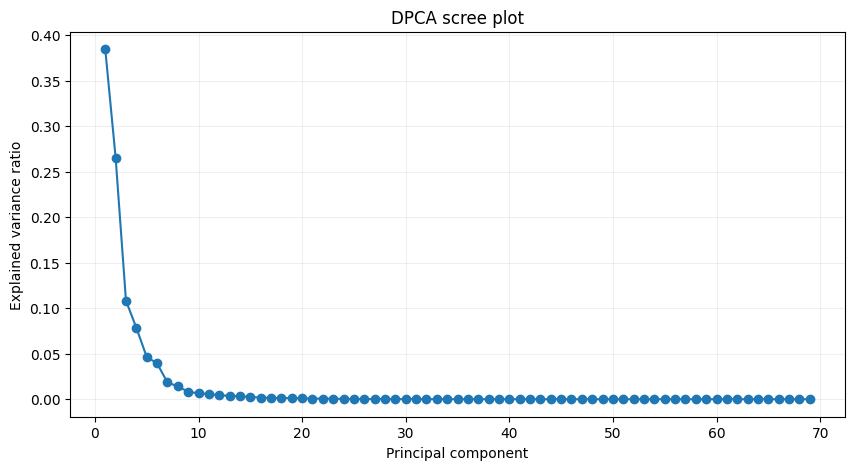

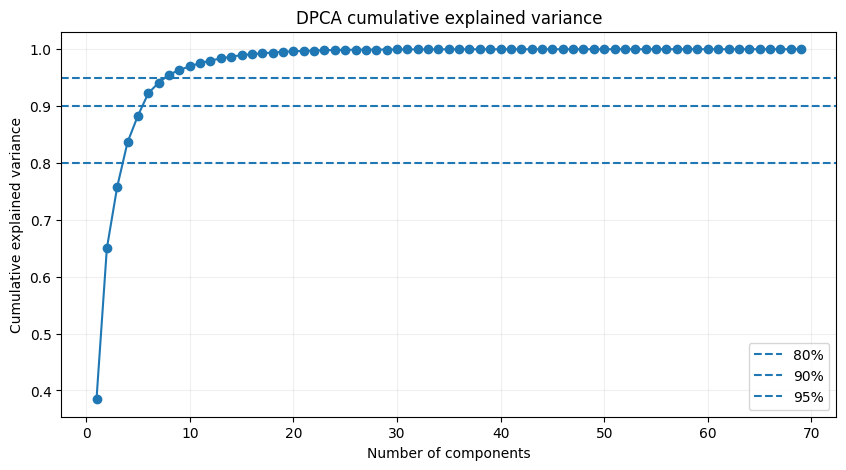

Components needed for 95% variance: 8


In [6]:
plt.figure(figsize=(10, 5))
plt.plot(dpca_variance_df["component"], dpca_variance_df["explained_variance_ratio"], marker="o")
plt.title("DPCA scree plot")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(dpca_variance_df["component"], dpca_variance_df["cumulative_variance"], marker="o")
plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.title("DPCA cumulative explained variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Components needed for 95% variance:", n_95)

## Vælg antal komponenter og beregn T2 threshold

Vælger antal DPCA-komponenter og beregner Hotelling T2-grænsen. Dette svarer til PCA notebooken

In [7]:
n_components = min(n_95, X_train.shape[1] - 1)

P = eigenvectors[:, :n_components]
lambda_inv = np.diag(1.0 / eigenvalues[:n_components])

n = X_train.shape[0]
a = n_components
alpha = 0.05

F_limit = f.ppf(1 - alpha, a, n - a)
T2_limit = (a * (n - 1) * (n + 1)) / (n * (n - a)) * F_limit

print("Retained DPCA components:", n_components)
print("T2 threshold:", T2_limit)

Retained DPCA components: 8
T2 threshold: 15.57550195420846


## Q/SPE threshold 

Beregner residualrummet. Q/SPE måler det, som DPCA-modellen ikke kunne forklare. Unversingen siger, at T2 og Q/SPE opdager forskellige typer fejl, og at begge bør bruges. 

In [8]:
T_train = X_train @ P
X_train_hat = T_train @ P.T
E_train = X_train - X_train_hat

Q_train = np.sum(E_train ** 2, axis=1)

Q_alpha = 0.95
Q_limit = np.quantile(Q_train, Q_alpha)

print("Q/SPE threshold:", Q_limit)

Q/SPE threshold: 7.951707941161701


## DPCA detection function 

Kører DPCA fault detection på et nyt datasæt. 

Returnerer: 
- T2: unormal variation i DPCA-rummet
- Q: Residualfejl uden for modellen 
- alarm_T2
- alarm_q
- alarm_combined 

In [9]:
def dpca_detect(dataset):
    dataset_scaled = dpca_preprocessor.transform(dataset)
    X = dataset_scaled.to_numpy()

    scores = X @ P

    T2 = np.sum((scores @ lambda_inv) * scores, axis=1)

    X_hat = scores @ P.T
    residuals = X - X_hat

    Q = np.sum(residuals ** 2, axis=1)

    alarm_T2 = T2 > T2_limit
    alarm_Q = Q > Q_limit
    alarm_combined = alarm_T2 | alarm_Q

    return T2, Q, alarm_T2, alarm_Q, alarm_combined, scores, residuals

## Kør DPCA og plot T2 + Q/SPE

Kører DPCA på alle datasæt og plotter T2 og Q/SPE. 

Bemærk: Fault-start flyttes med lag_length, fordi DPCA dropper de første L rækker 

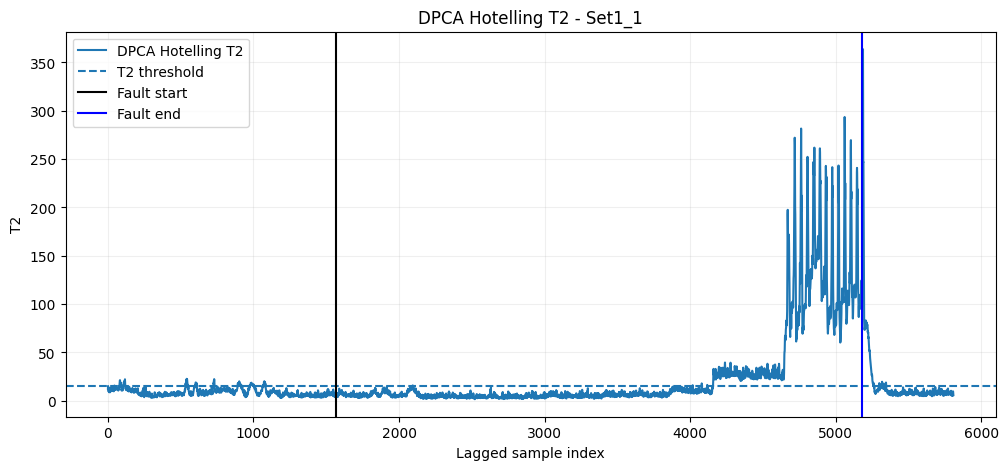

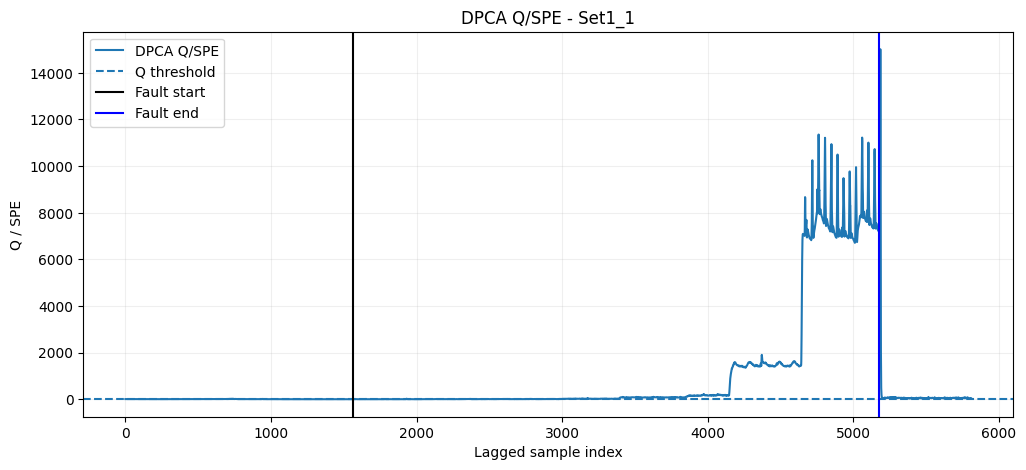

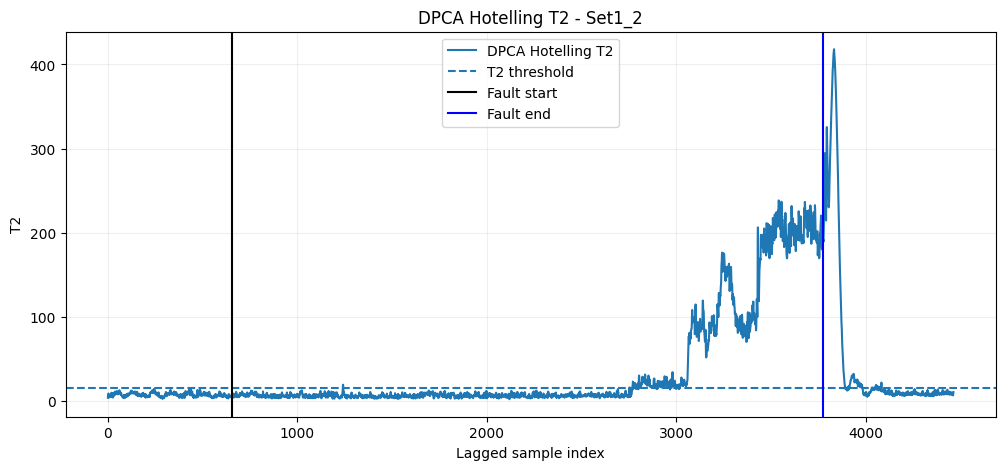

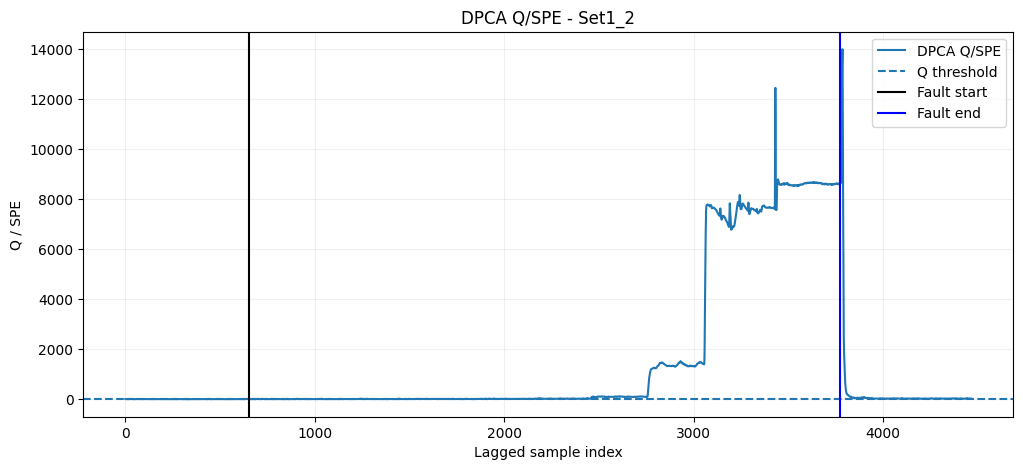

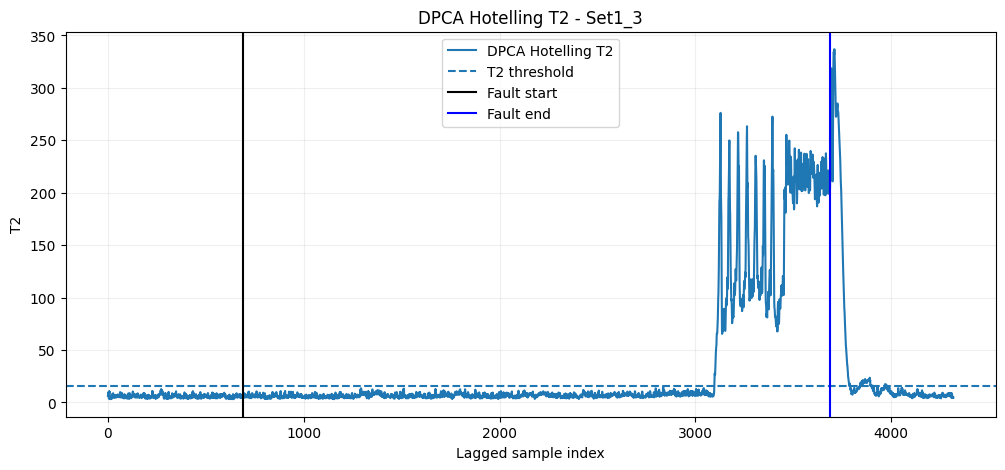

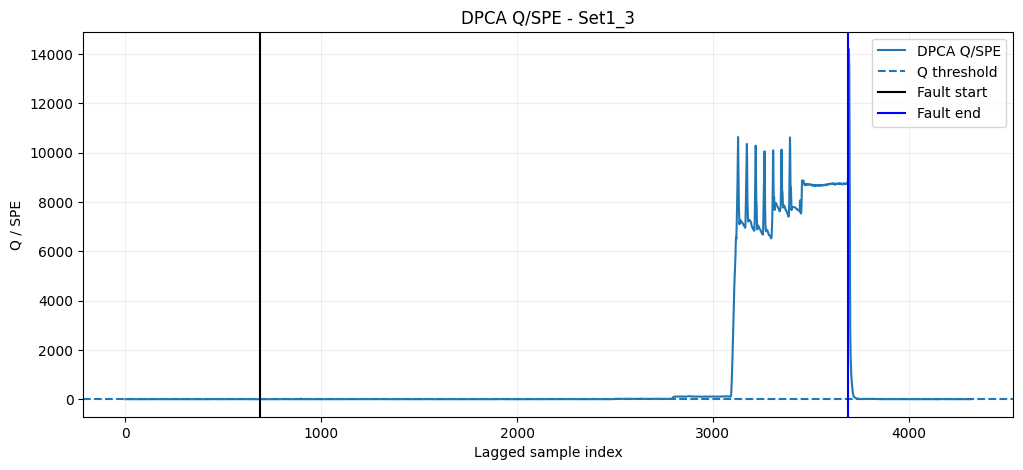

In [10]:
dpca_results = {}

for name, dataset in datasets.items():
    fault_start_original = fault_info[name]["start"]
    fault_end_original = fault_info[name]["end"]

    adjusted_fault_start = max(fault_start_original - lag_length, 0)
    adjusted_fault_end = max(fault_end_original - lag_length, 0)

    T2, Q, alarm_T2, alarm_Q, alarm_combined, scores, residuals = dpca_detect(dataset)

    dpca_results[name] = {
        "T2": T2,
        "Q": Q,
        "alarm_T2": alarm_T2,
        "alarm_Q": alarm_Q,
        "alarm_combined": alarm_combined,
        "scores": scores,
        "residuals": residuals,
        "adjusted_fault_start": adjusted_fault_start,
        "adjusted_fault_end": adjusted_fault_end,
    }

    plt.figure(figsize=(12, 5))
    plt.plot(T2, label="DPCA Hotelling T2")
    plt.axhline(T2_limit, linestyle="--", label="T2 threshold")
    plt.axvline(adjusted_fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(adjusted_fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"DPCA Hotelling T2 - {name}")
    plt.xlabel("Lagged sample index")
    plt.ylabel("T2")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(Q, label="DPCA Q/SPE")
    plt.axhline(Q_limit, linestyle="--", label="Q threshold")
    plt.axvline(adjusted_fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(adjusted_fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"DPCA Q/SPE - {name}")
    plt.xlabel("Lagged sample index")
    plt.ylabel("Q / SPE")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## Binære alarmplots 

Viser T2-alarm, Q-alarm og samlet alarm som 0/1.

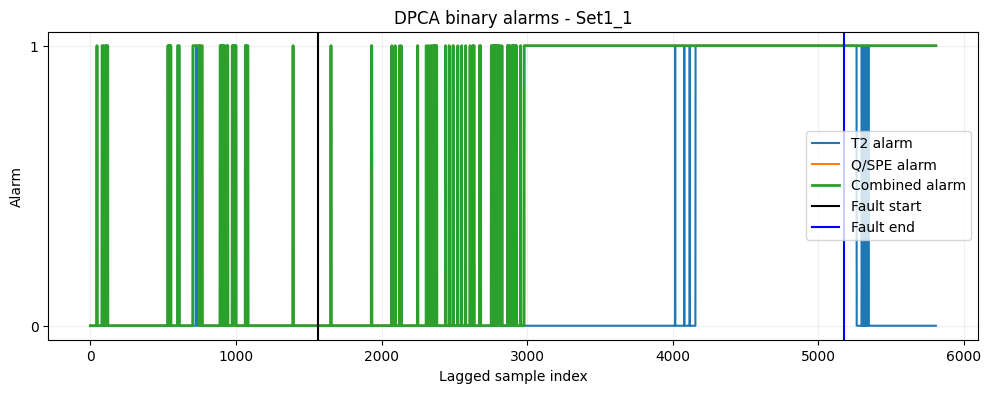

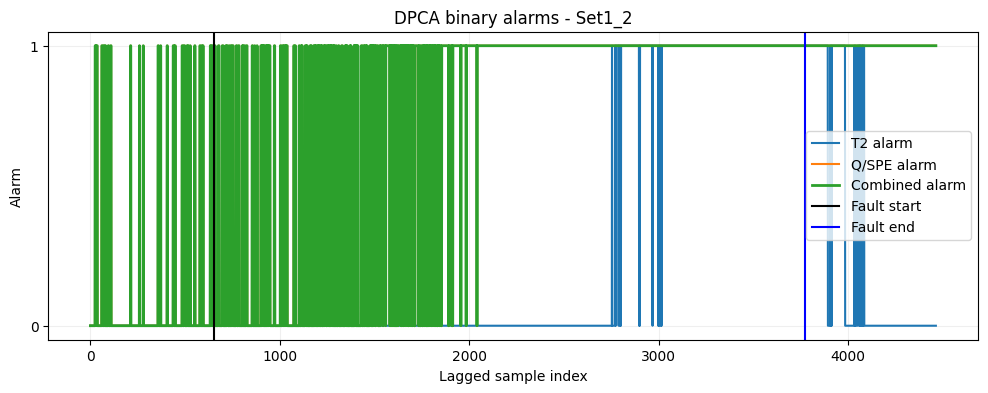

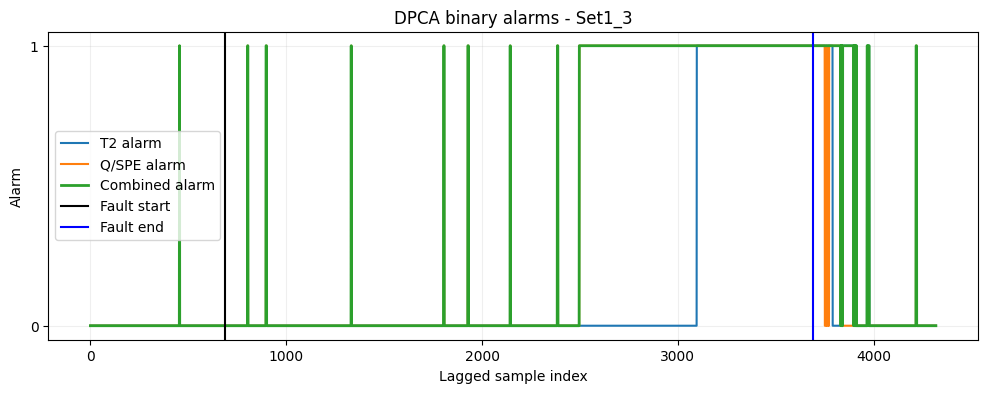

In [11]:
for name, result in dpca_results.items():
    fault_start = result["adjusted_fault_start"]
    fault_end = result["adjusted_fault_end"]

    plt.figure(figsize=(12, 4))
    plt.plot(result["alarm_T2"].astype(int), label="T2 alarm")
    plt.plot(result["alarm_Q"].astype(int), label="Q/SPE alarm")
    plt.plot(result["alarm_combined"].astype(int), label="Combined alarm", linewidth=2)
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"DPCA binary alarms - {name}")
    plt.xlabel("Lagged sample index")
    plt.ylabel("Alarm")
    plt.yticks([0, 1])
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## DPCA summary table 

Laver samme type summary-tabel som PCA, bare med DPCA

In [12]:
dpca_rows = []

for name, result in dpca_results.items():
    fault_start = result["adjusted_fault_start"]
    fault_end = result["adjusted_fault_end"]

    for model_name, alarm_values in {
        "DPCA T2": result["alarm_T2"],
        "DPCA Q/SPE": result["alarm_Q"],
        "DPCA T2 OR Q": result["alarm_combined"],
    }.items():

        metrics = evaluate_alarm(
            alarm_values,
            fault_start,
            fault_end,
        )

        dpca_rows.append({
            "Dataset": name,
            "Model": model_name,
            "lag_length": lag_length,
            "n_components": n_components,
            **metrics,
        })

dpca_summary_df = pd.DataFrame(dpca_rows)
display(dpca_summary_df)

,Dataset,Model,lag_length,n_components,first_alarm_after_fault,detection_delay,n_alarms_total,n_alarms_before_fault,n_alarms_during_fault,n_alarms_after_fault,false_alarm_rate_before_fault,fault_detection_rate
0,Set1_1,DPCA T2,2,8,2093,529,1258,126,1029,103,0.080563,0.284569
1,Set1_1,DPCA Q/SPE,2,8,1652,88,3004,66,2309,629,0.042199,0.638551
2,Set1_1,DPCA T2 OR Q,2,8,1652,88,3123,183,2311,629,0.117008,0.639104
3,Set1_2,DPCA T2,2,8,1241,586,1209,0,993,216,0.000000,0.318167
4,Set1_2,DPCA Q/SPE,2,8,658,3,3170,75,2406,689,0.114504,0.770907
5,Set1_2,DPCA T2 OR Q,2,8,658,3,3170,75,2406,689,0.114504,0.770907
6,Set1_3,DPCA T2,2,8,3097,2408,763,0,593,170,0.000000,0.197601
7,Set1_3,DPCA Q/SPE,2,8,803,114,1344,1,1208,135,0.001451,0.402532
8,Set1_3,DPCA T2 OR Q,2,8,803,114,1430,1,1208,221,0.001451,0.402532


## DPCA score plot

Viser DPCA-scores. Det hjælper med at se, om fault perioden bevæger sig væk fra normalområdet

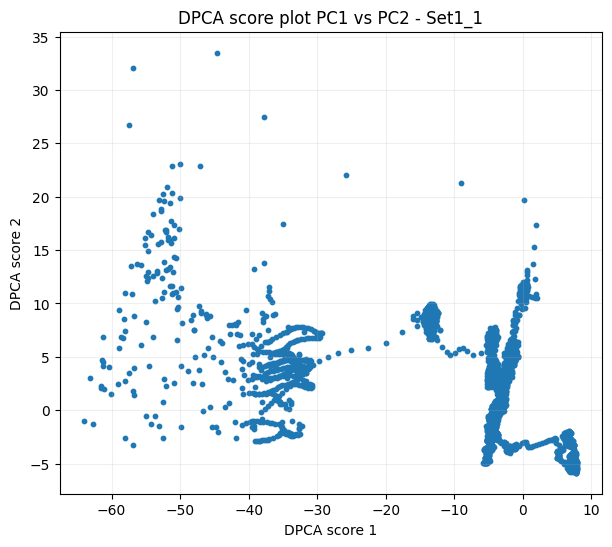

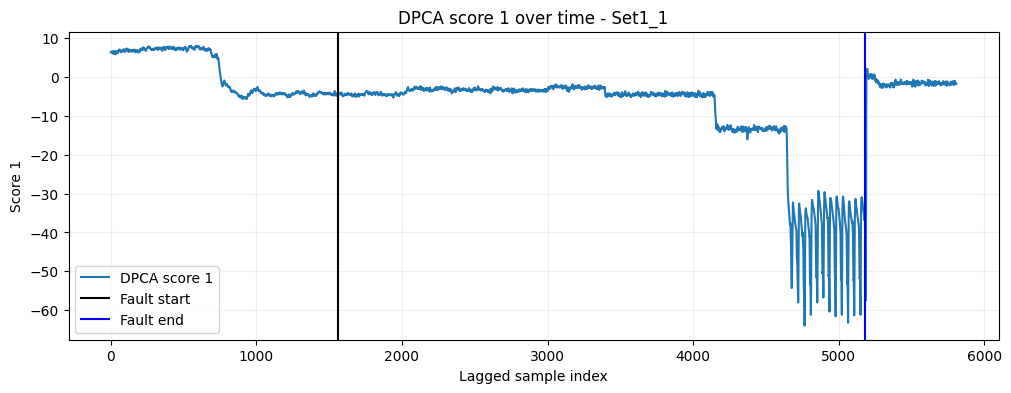

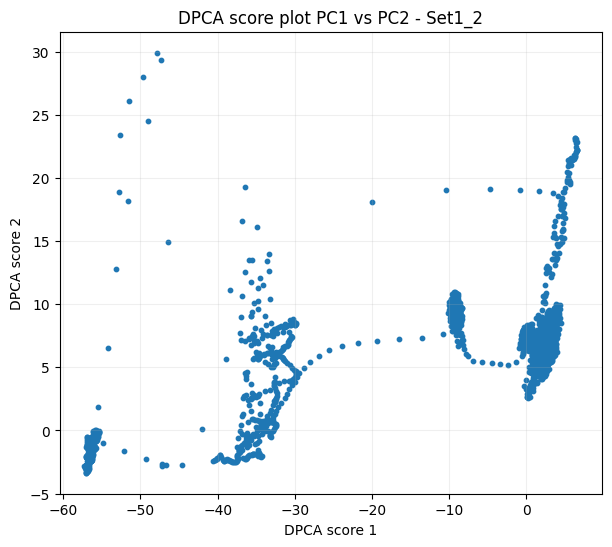

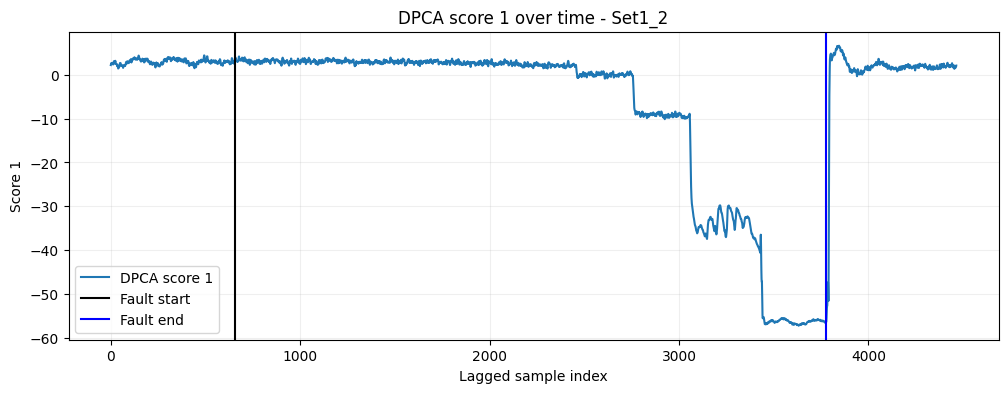

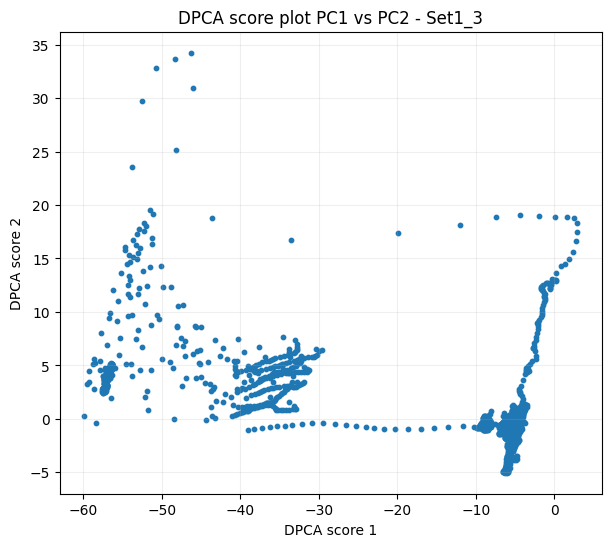

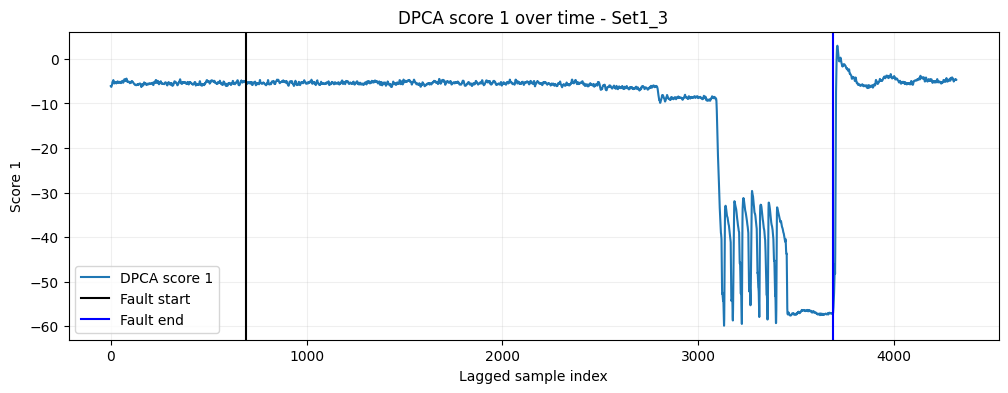

In [13]:
for name, result in dpca_results.items():
    scores = result["scores"]
    fault_start = result["adjusted_fault_start"]
    fault_end = result["adjusted_fault_end"]

    if scores.shape[1] >= 2:
        plt.figure(figsize=(7, 6))
        plt.scatter(scores[:, 0], scores[:, 1], s=10)
        plt.title(f"DPCA score plot PC1 vs PC2 - {name}")
        plt.xlabel("DPCA score 1")
        plt.ylabel("DPCA score 2")
        plt.grid(True, alpha=0.2)
        plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(scores[:, 0], label="DPCA score 1")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"DPCA score 1 over time - {name}")
    plt.xlabel("Lagged sample index")
    plt.ylabel("Score 1")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()